# Segmentación de Clientes en Transacciones Retail

## Problema de negocio

Las empresas de retail suelen tratar a todos sus clientes de la misma manera, aunque el comportamiento de compra varía enormemente entre ellos. No todos responden igual a las promociones, generan el mismo valor ni compran con la misma frecuencia. Tratar a todos por igual limita la efectividad de las estrategias de marketing, retención y precios.

Este proyecto responde una pregunta sencilla pero de alto impacto:

> **¿Qué tipos de clientes existen en este negocio retail, según su comportamiento real de compra?**

Los segmentos resultantes pueden apoyar estrategias de marketing dirigido, promociones, retención de clientes y decisiones de precios.

## Objetivo

Identificar segmentos naturales de clientes usando técnicas de clustering y reducción de dimensionalidad, con el fin de generar hallazgos accionables orientados al negocio.

## Metodología

1. Limpieza de datos
2. Feature engineering a nivel cliente (transacciones, gasto, uso de descuentos y promociones)
3. Escalado de variables
4. Clustering con KMeans (k seleccionado mediante el método del codo)
5. Visualización con PCA
6. Interpretación de clusters

In [1]:
import kagglehub
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Descargar el dataset desde Kaggle
path = kagglehub.dataset_download("prasad22/retail-transactions-dataset")


## Dataset

El dataset contiene transacciones retail con la siguiente información por registro:

- Transacciones por cliente
- Productos comprados
- Gasto total
- Uso de promociones y descuentos
- Información de tienda y ciudad

In [3]:
csv_path = os.path.join(
    path,
    "Retail_Transactions_Dataset.csv"
)

df = pd.read_csv(csv_path)

df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


**Nota sobre granularidad de los datos:** Los clientes están identificados por nombre en lugar de un ID único. Esto significa que clientes distintos con el mismo nombre quedan agrupados como si fueran una sola persona. Esta es una limitación del dataset sintético que se resolvería con un ID de cliente real en un entorno de producción.

In [4]:
# Verificar nombres repetidos — confirma que el dataset usa nombres en lugar de IDs únicos
df["Customer_Name"].value_counts().head(10)

Customer_Name
Michael Smith        454
Michael Johnson      341
James Smith          337
David Smith          309
Michael Williams     304
Christopher Smith    301
John Smith           288
Michael Jones        285
Robert Smith         275
Michael Brown        274
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  object 
 2   Customer_Name      1000000 non-null  object 
 3   Product            1000000 non-null  object 
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  object 
 7   City               1000000 non-null  object 
 8   Store_Type         1000000 non-null  object 
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  object 
 11  Season             1000000 non-null  object 
 12  Promotion          666057 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 92.5+ MB


## Feature Engineering

Los datos transaccionales se agregaron a nivel cliente para crear variables de comportamiento:

- Total de transacciones
- Gasto total
- Valor promedio por transacción
- Total de productos comprados
- Tasa de uso de descuentos
- Tasa de compras en promociones

In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df["Promotion"] = df["Promotion"].notna().astype(int)
df["Date"] = pd.to_datetime(df["Date"])

customer_df = df.groupby("Customer_Name").agg({
    "Transaction_ID": "count",
    "Total_Cost": ["sum", "mean"],
    "Total_Items": "sum",
    "Discount_Applied": "mean",
    "Promotion": "mean"
})


customer_df.columns = [
    "total_transactions",
    "total_spent",
    "avg_transaction_value",
    "total_items",
    "discount_rate",
    "promotion_rate"
]

customer_df.head()

,total_transactions,total_spent,avg_transaction_value,total_items,discount_rate,promotion_rate
Customer_Name,,,,,,
Aaron Acevedo,4,279.85,69.962500,13,0.500000,0.500000
Aaron Acosta,3,215.32,71.773333,13,0.666667,1.000000
Aaron Adams,12,772.36,64.363333,77,0.333333,0.666667
Aaron Adkins,3,118.52,39.506667,11,0.000000,0.333333
Aaron Aguilar,5,236.76,47.352000,32,0.200000,0.600000


In [7]:
# Estandarizar variables (media=0, std=1) para que ninguna domine por su escala
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df)

In [8]:
# Método del codo: encontrar k donde los clusters adicionales dejan de reducir significativamente la inercia
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

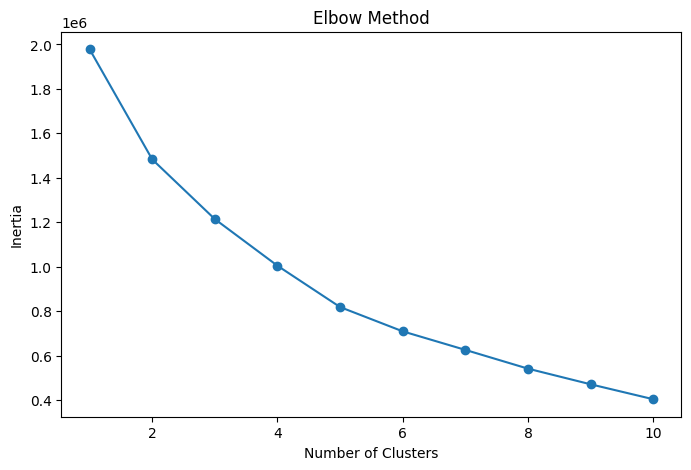

In [9]:
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,  # seleccionado con base en el método del codo
    random_state=42,
    n_init=10
)
customer_df["cluster"] = kmeans.fit_predict(scaled_features)

In [11]:
customer_df.head()

,total_transactions,total_spent,avg_transaction_value,total_items,discount_rate,promotion_rate,cluster
Customer_Name,,,,,,,
Aaron Acevedo,4,279.85,69.962500,13,0.500000,0.500000,2
Aaron Acosta,3,215.32,71.773333,13,0.666667,1.000000,0
Aaron Adams,12,772.36,64.363333,77,0.333333,0.666667,4
Aaron Adkins,3,118.52,39.506667,11,0.000000,0.333333,2
Aaron Aguilar,5,236.76,47.352000,32,0.200000,0.600000,1


In [12]:
cluster_summary = customer_df.groupby("cluster").mean()

cluster_summary

,total_transactions,total_spent,avg_transaction_value,total_items,discount_rate,promotion_rate
cluster,,,,,,
0,2.121242,111.006476,52.398933,11.614127,0.928633,0.901185
1,2.414100,125.836429,52.268475,13.244341,0.149091,0.902450
2,1.821836,95.542185,52.494904,9.992037,0.498881,0.128299
3,96.139013,5061.609821,52.701755,528.445441,0.503233,0.665289
4,19.441540,1028.172809,53.221315,107.532844,0.501269,0.663519


# Hallazgos Clave

## 1. El ticket promedio es estable en todos los segmentos — lo que diferencia al cliente es la frecuencia

El valor promedio por transacción se mantiene casi constante en todos los clusters (~$52), independientemente de con qué frecuencia compra el cliente o cuánto gasta en total. Esto significa que el valor del cliente no está determinado por el tamaño del carrito, sino por la frecuencia de visita.

## 2. Los segmentos difieren principalmente en lealtad y comportamiento frente a descuentos y promociones

- **Cluster 0** — Compradores poco frecuentes (~2 transacciones en promedio) que dependen fuertemente de descuentos y períodos promocionales (~90% en ambos casos). Compran principalmente cuando hay un incentivo.
- **Cluster 1** — Frecuencia baja similar al Cluster 0, gasto ligeramente mayor, pero sus compras se concentran casi exclusivamente en períodos promocionales más que en artículos con descuento específico.
- **Cluster 2** — Compradores esporádicos que usan descuentos pero fuera de períodos promocionales. Buscan artículos con descuento, no campañas de promoción.
- **Cluster 3** — Clientes leales de alto valor. Compran con frecuencia, gastan más en total y aprovechan tanto descuentos como promociones en aproximadamente la mitad de sus compras.
- **Cluster 4** — También leales y frecuentes, pero con ticket promedio menor al Cluster 3. Compran seguido pero prefieren productos más económicos.

## 3. Implicación de negocio: el foco debe estar en frecuencia y retención, no en el ticket

Como el ticket promedio ya es estable entre segmentos, incrementarlo no es la palanca de mayor impacto. Los datos apuntan hacia **aumentar la frecuencia de compra y la retención** — particularmente convertir segmentos poco frecuentes impulsados por descuentos (0, 1, 2) en clientes más leales y frecuentes (3, 4).

## PCA — Reducción de dimensionalidad para visualización

El clustering con KMeans se realizó usando las seis variables de comportamiento. Para visualizar los segmentos en dos dimensiones, se aplicó PCA únicamente con fines de visualización — no afecta el clustering en sí.

Los dos componentes resultantes se alinean con los patrones identificados arriba:

- **PC1** está dominado por volumen de compra (transacciones totales, gasto total, productos totales) — separa clientes frecuentes de alta actividad frente a clientes poco frecuentes.
- **PC2** está dominado por el valor promedio por transacción y el uso de promociones — separa clientes según *cómo* compran, no con qué frecuencia.

In [13]:
# Reducir a 2 componentes únicamente para visualización —
# el clustering ya se realizó sobre las 6 variables originales
pca = PCA(n_components=2)

pca_components = pca.fit_transform(
    scaled_features
)

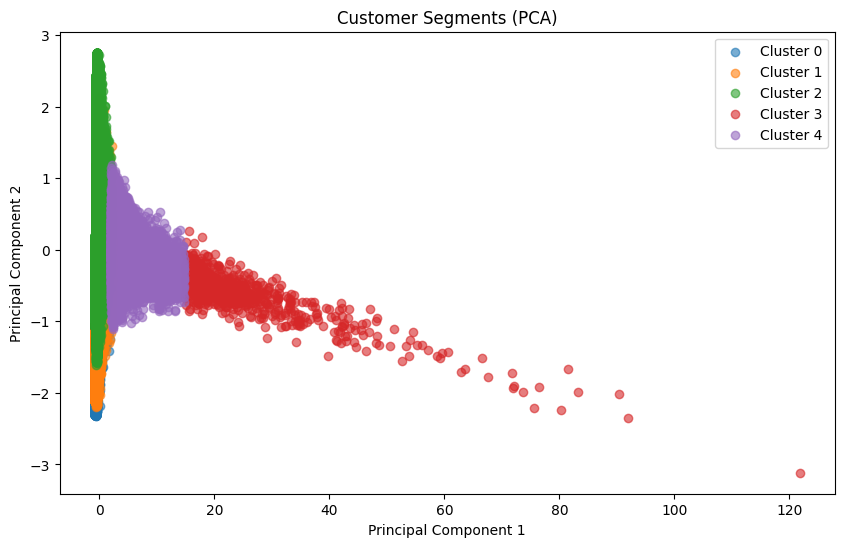

In [14]:
pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"]
)
pca_df["cluster"] = customer_df["cluster"].values

plt.figure(figsize=(10,6))
for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}", alpha=0.5, s=10)

plt.xlabel("PC1 — Volumen de compra")
plt.ylabel("PC2 — Ticket promedio y promociones")
plt.title("Segmentos de clientes visualizados con PCA")
plt.legend(title="Cluster")
plt.show()

Esto confirma que los segmentos están separados principalmente por frecuencia de compra (PC1), con el comportamiento frente a promociones como eje secundario de variación (PC2), lo cual es consistente con los hallazgos a nivel de cluster descritos arriba.

**Detalles de componentes — Pesos de variables:**

In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=customer_df.drop("cluster", axis=1).columns
)

loadings

,PC1,PC2
total_transactions,0.578061,-0.043123
total_spent,0.577107,0.042939
avg_transaction_value,0.029331,0.871104
total_items,0.576135,-0.043641
discount_rate,0.000151,-0.076785
promotion_rate,0.000518,-0.479243


In [16]:
# Muestra de 10,000 clientes — calcular silhouette sobre los ~700K totales es demasiado lento
sample_df = customer_df.sample(
    10000,
    random_state=42
)
sample_scaled = scaler.transform(
    sample_df.drop("cluster", axis=1)
)

In [17]:
score = silhouette_score(
    sample_scaled,
    sample_df["cluster"]
)

print(score)

0.2851972107404993


**Sobre la separación de clusters:** El silhouette score (0.29) indica una superposición moderada entre grupos en lugar de clusters perfectamente definidos. Esto es esperable dado el origen sintético del dataset y la limitación de usar nombres en lugar de IDs únicos mencionada anteriormente. En un entorno real con IDs de cliente reales e historiales de compra más largos, se esperaría una separación más clara.

# Conclusión

Este proyecto demuestra cómo aplicar técnicas de aprendizaje no supervisado a datos transaccionales de retail para identificar patrones de comportamiento de clientes y generar hallazgos orientados al negocio. Los segmentos identificados sugieren que la retención y la frecuencia de compra — no el ticket promedio — son las palancas más prometedoras para aumentar el valor del cliente.